# Case iFood, Notebook 1: Processamento de Dados (PySpark)

Este notebook lê os três arquivos brutos de `data/raw/`, explora e trata os dados, reconstrói a jornada de cada oferta enviada e gera o dataset unificado no nível (cliente, oferta recebida), com a variável alvo `converteu`, em `data/processed/`.

Roda localmente com `pyspark` (a sessão `local[*]` é criada abaixo). No Databricks Community Edition basta ajustar os caminhos para o DBFS, pois o `getOrCreate()` reaproveita a sessão do cluster.

In [1]:
import os
import sys

os.environ.setdefault("PYSPARK_PYTHON", sys.executable)

from pathlib import Path

import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window
from pyspark.sql import functions as F

spark = (
    SparkSession.builder.appName("ifood_case")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW = RAIZ / "data" / "raw"
PROCESSED = RAIZ / "data" / "processed"
PROCESSED.mkdir(parents=True, exist_ok=True)

AZUL = "#2a78d6"
COR_POR_TIPO = {"bogo": "#2a78d6", "discount": "#1baf7a", "informational": "#eda100"}
plt.rcParams.update({
    "figure.figsize": (9, 3.5),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("Spark", spark.version)

Spark 3.5.8


## 1. Leitura

Os três JSONs são arrays em linha única, por isso a leitura usa `multiLine=True`.

In [2]:
ofertas_raw = spark.read.option("multiLine", True).json(str(RAW / "offers.json"))
clientes_raw = spark.read.option("multiLine", True).json(str(RAW / "profile.json"))
transacoes_raw = spark.read.option("multiLine", True).json(str(RAW / "transactions.json"))

print(f"ofertas: {ofertas_raw.count()} | clientes: {clientes_raw.count()} | eventos: {transacoes_raw.count()}")
transacoes_raw.printSchema()

ofertas: 10 | clientes: 17000 | eventos: 306534
root
 |-- account_id: string (nullable = true)
 |-- event: string (nullable = true)
 |-- time_since_test_start: double (nullable = true)
 |-- value: struct (nullable = true)
 |    |-- amount: double (nullable = true)
 |    |-- offer id: string (nullable = true)
 |    |-- offer_id: string (nullable = true)
 |    |-- reward: double (nullable = true)



Volumetria conforme o enunciado: 10 ofertas, 17.000 clientes e 306.534 eventos. O campo `value` é um struct com quatro chaves (`amount`, `offer id`, `offer_id`, `reward`), uma inconsistência de nomenclatura tratada no parsing.

## 2. Análise exploratória

### 2.1 Portfólio de ofertas

In [3]:
ofertas_raw.select("id", "offer_type", "min_value", "discount_value", "duration", "channels").orderBy("offer_type", "min_value").toPandas()

,id,offer_type,min_value,discount_value,duration,channels
0,9b98b8c7a33c4b65b9aebfe6a799e6d9,bogo,5,5,7.0,"[web, email, mobile]"
1,f19421c1d4aa40978ebb69ca19b0e20d,bogo,5,5,5.0,"[web, email, mobile, social]"
2,ae264e3637204a6fb9bb56bc8210ddfd,bogo,10,10,7.0,"[email, mobile, social]"
3,4d5c57ea9a6940dd891ad53e9dbe8da0,bogo,10,10,5.0,"[web, email, mobile, social]"
4,2298d6c36e964ae4a3e7e9706d1fb8c2,discount,7,3,7.0,"[web, email, mobile, social]"
5,fafdcd668e3743c1bb461111dcafc2a4,discount,10,2,10.0,"[web, email, mobile, social]"
6,2906b810c7d4411798c6938adc9daaa5,discount,10,2,7.0,"[web, email, mobile]"
7,0b1e1539f2cc45b7b9fa7c272da2e1d7,discount,20,5,10.0,"[web, email]"
8,3f207df678b143eea3cee63160fa8bed,informational,0,0,4.0,"[web, email, mobile]"
9,5a8bc65990b245e5a138643cd4eb9837,informational,0,0,3.0,"[email, mobile, social]"


São 4 ofertas BOGO, 4 de desconto e 2 informacionais (sem desconto nem gasto mínimo). A duração varia de 3 a 10 dias e define a janela de validade de cada envio. Todas saem por e-mail, então o canal só diferencia nas combinações com mobile, web e social.

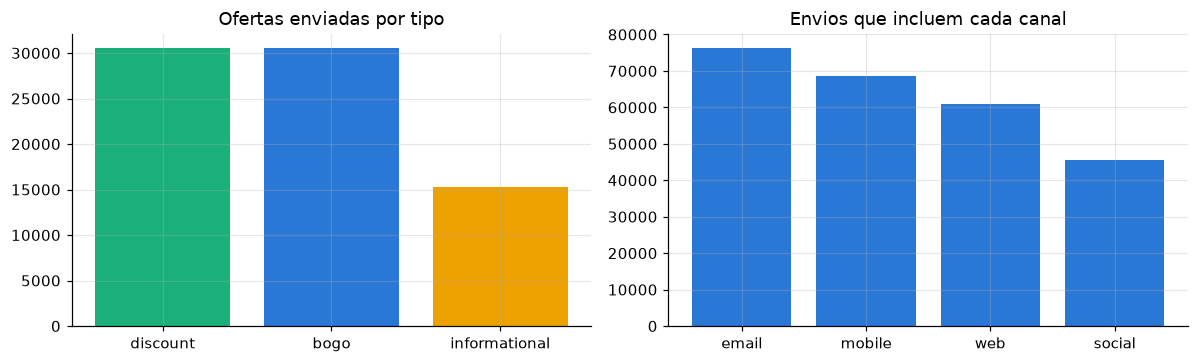

In [4]:
recebidas = transacoes_raw.filter(F.col("event") == "offer received").select(
    F.col("value").getField("offer id").alias("id_oferta")
)
por_tipo = (
    recebidas.join(ofertas_raw.select(F.col("id").alias("id_oferta"), "offer_type"), "id_oferta")
    .groupBy("offer_type").count().orderBy(F.desc("count")).toPandas()
)
por_canal = (
    recebidas.join(ofertas_raw.select(F.col("id").alias("id_oferta"), F.explode("channels").alias("canal")), "id_oferta")
    .groupBy("canal").count().orderBy(F.desc("count")).toPandas()
)

fig, eixos = plt.subplots(1, 2, figsize=(11, 3.4))
eixos[0].bar(por_tipo["offer_type"], por_tipo["count"], color=[COR_POR_TIPO[t] for t in por_tipo["offer_type"]])
eixos[0].set_title("Ofertas enviadas por tipo")
eixos[1].bar(por_canal["canal"], por_canal["count"], color=AZUL)
eixos[1].set_title("Envios que incluem cada canal")
fig.tight_layout()
plt.show()

### 2.2 Clientes

A idade 118 parece placeholder de cadastro. Verificamos a coincidência com os nulos de gênero e limite.

In [5]:
clientes_raw.groupBy(
    (F.col("age") == 118).alias("idade_118"),
    F.col("gender").isNull().alias("genero_nulo"),
    F.col("credit_card_limit").isNull().alias("limite_nulo"),
).count().show()

clientes_raw.groupBy("gender").count().orderBy(F.desc("count")).show()
clientes_raw.filter(F.col("age") != 118).select("age", "credit_card_limit").summary("min", "50%", "max", "mean").show()

+---------+-----------+-----------+-----+
|idade_118|genero_nulo|limite_nulo|count|
+---------+-----------+-----------+-----+
|    false|      false|      false|14825|
|     true|       true|       true| 2175|
+---------+-----------+-----------+-----+



+------+-----+
|gender|count|
+------+-----+
|     M| 8484|
|     F| 6129|
|  NULL| 2175|
|     O|  212|
+------+-----+



+-------+-----------------+-----------------+
|summary|              age|credit_card_limit|
+-------+-----------------+-----------------+
|    min|               18|          30000.0|
|    50%|               55|          64000.0|
|    max|              101|         120000.0|
|   mean|54.39352445193929| 65404.9915682968|
+-------+-----------------+-----------------+



A coincidência é perfeita: os mesmos 2.175 clientes (12,8% da base) têm idade 118, gênero nulo e limite nulo. É um único padrão de cadastro incompleto. Eles receberam ofertas e transacionaram normalmente, então não devem ser descartados nem imputados com média: anulamos a idade e marcamos o grupo com a flag `cadastro_incompleto`.

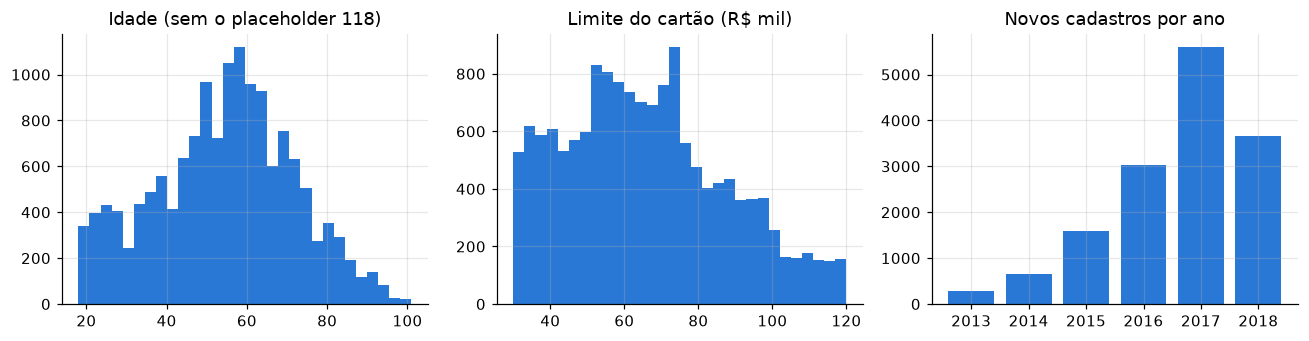

In [6]:
demografia = clientes_raw.filter(F.col("age") != 118).select("age", "credit_card_limit", F.substring("registered_on", 1, 4).alias("ano")).toPandas()

fig, eixos = plt.subplots(1, 3, figsize=(12, 3.2))
eixos[0].hist(demografia["age"], bins=30, color=AZUL)
eixos[0].set_title("Idade (sem o placeholder 118)")
eixos[1].hist(demografia["credit_card_limit"] / 1000, bins=30, color=AZUL)
eixos[1].set_title("Limite do cartão (R$ mil)")
contagem_ano = demografia["ano"].value_counts().sort_index()
eixos[2].bar(contagem_ano.index, contagem_ano.values, color=AZUL)
eixos[2].set_title("Novos cadastros por ano")
fig.tight_layout()
plt.show()

Base adulta com mediana de 55 anos e limite mediano de R\$ 64 mil. Os cadastros crescem até 2017, com 2018 parcial (o teste ocorre em meados de 2018), o que torna o tempo de cadastro uma feature relevante.

### 2.3 Transações

In [7]:
valores = transacoes_raw.filter(F.col("event") == "transaction").select(F.col("value").getField("amount").alias("valor"))
valores.summary("min", "25%", "50%", "75%", "99%", "max").show()
print("compras acima de R$ 100:", valores.filter(F.col("valor") > 100).count())

transacoes_raw.filter(F.col("event") == "offer received").groupBy(
    F.col("time_since_test_start").alias("dia_envio")
).count().orderBy("dia_envio").show()

+-------+-------+
|summary|  valor|
+-------+-------+
|    min|   0.05|
|    25%|   2.78|
|    50%|   8.89|
|    75%|  18.06|
|    99%|  40.05|
|    max|1062.28|
+-------+-------+



compras acima de R$ 100: 478


+---------+-----+
|dia_envio|count|
+---------+-----+
|      0.0|12650|
|      7.0|12669|
|     14.0|12711|
|     17.0|12778|
|     21.0|12704|
|     24.0|12765|
+---------+-----+



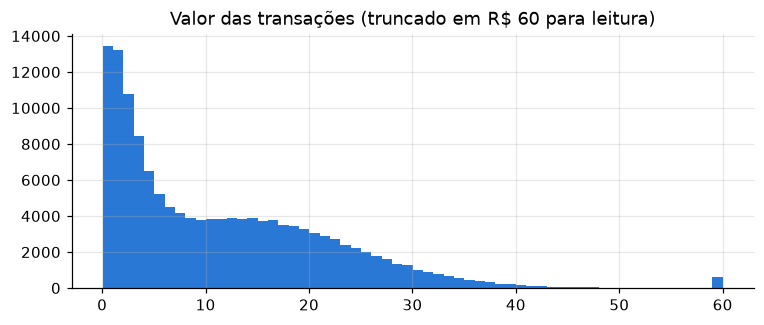

In [8]:
valores_pd = valores.toPandas()
plt.figure(figsize=(8, 3))
plt.hist(valores_pd["valor"].clip(upper=60), bins=60, color=AZUL)
plt.title("Valor das transações (truncado em R$ 60 para leitura)")
plt.show()

Três leituras importantes:

- `time_since_test_start` está em dias (0 a 29,75), mesma unidade de `duration`: a janela de validade é simplesmente `dia_recebimento + duracao`.
- As ofertas saíram em 6 ondas (dias 0, 7, 14, 17, 21 e 24) e o mesmo par (cliente, oferta) se repete em milhares de casos. O grão correto do dataset é o evento de recebimento, não o par.
- O valor de transação tem cauda longa (mediana de R\$ 9, máximo de R\$ 1.062), mas só 0,3% das compras passam de R\$ 100. Sem evidência de erro de captura, mantemos os valores: são receita real.

## 3. Limpeza e tratamento

- Idade 118 vira nulo e o grupo ganha a flag `cadastro_incompleto`.
- Gênero nulo vira a categoria `desconhecido`, preservando o segmento como informação.
- Limite nulo fica nulo: a imputação é papel do pipeline de modelagem, calculada só no treino, e o LightGBM lida com nulos nativamente.
- `registered_on` vira data, e derivamos `tempo_cadastro_dias` usando a maior data de cadastro como referência (proxy do início do teste).
- Outliers de transação são mantidos, e as colunas passam a nomes em português.

In [9]:
data_referencia = clientes_raw.select(F.max(F.to_date("registered_on", "yyyyMMdd"))).first()[0]

clientes = (
    clientes_raw.select(
        F.col("id").alias("id_cliente"),
        F.when(F.col("age") == 118, None).otherwise(F.col("age")).alias("idade"),
        F.coalesce(F.col("gender"), F.lit("desconhecido")).alias("genero"),
        F.col("credit_card_limit").alias("limite_cartao"),
        F.to_date("registered_on", "yyyyMMdd").alias("data_cadastro"),
    )
    .withColumn("cadastro_incompleto", F.col("idade").isNull().cast("int"))
    .withColumn("tempo_cadastro_dias", F.datediff(F.lit(data_referencia), F.col("data_cadastro")))
    .withColumn("ano_cadastro", F.year("data_cadastro"))
    .drop("data_cadastro")
)

ofertas = (
    ofertas_raw.select(
        F.col("id").alias("id_oferta"),
        F.col("offer_type").alias("tipo_oferta"),
        F.col("min_value").alias("valor_minimo"),
        F.col("duration").alias("duracao_dias"),
        F.col("discount_value").alias("valor_desconto"),
        F.size("channels").alias("num_canais"),
        F.array_contains("channels", "web").cast("int").alias("canal_web"),
        F.array_contains("channels", "email").cast("int").alias("canal_email"),
        F.array_contains("channels", "mobile").cast("int").alias("canal_mobile"),
        F.array_contains("channels", "social").cast("int").alias("canal_social"),
    )
)
clientes.limit(3).toPandas()

,id_cliente,idade,genero,limite_cartao,cadastro_incompleto,tempo_cadastro_dias,ano_cadastro
0,68be06ca386d4c31939f3a4f0e3dd783,NaN,desconhecido,NaN,1,529,2017
1,0610b486422d4921ae7d2bf64640c50b,55.0,F,112000.0,0,376,2017
2,38fe809add3b4fcf9315a9694bb96ff5,NaN,desconhecido,NaN,1,14,2018


## 4. Parsing do campo `value`

`offer received` e `offer viewed` gravam o id em `offer id` (com espaço), `offer completed` grava em `offer_id`, e `transaction` usa `amount`. O `coalesce` unifica as duas grafias. O `reward` do evento é redundante com o `discount_value` da oferta e não é usado.

In [10]:
eventos = (
    transacoes_raw.select(
        F.col("account_id").alias("id_cliente"),
        F.col("event").alias("evento"),
        F.col("time_since_test_start").alias("dia_evento"),
        F.coalesce(F.col("value").getField("offer id"), F.col("value").getField("offer_id")).alias("id_oferta"),
        F.col("value").getField("amount").alias("valor_transacao"),
    )
    .cache()
)
eventos.groupBy("evento").count().orderBy("evento").show()

+---------------+------+
|         evento| count|
+---------------+------+
|offer completed| 33579|
| offer received| 76277|
|   offer viewed| 57725|
|    transaction|138953|
+---------------+------+



## 5. Reconstrução da jornada da oferta

Cada evento `offer received` vira um envio, a unidade de análise, com janela de validade `[dia_recebimento, dia_recebimento + duracao]`. Regras de atribuição:

- Como janelas do mesmo par (cliente, oferta) podem se sobrepor, cada visualização ou conclusão é atribuída ao envio mais recente cuja janela a contém, e cada evento conta no máximo uma vez (atribuição de último toque).
- BOGO e desconto convertem quando o cliente viu a oferta e a completou depois de vê-la, dentro da janela.
- Conclusão sem visualização prévia é conversão acidental: o desconto foi creditado sem influência da comunicação, então `converteu = 0` com flag própria.
- Informacionais não têm evento de conclusão. Premissa: convertem quando o cliente vê a comunicação e transaciona até o fim da janela.
- Transações fora de qualquer janela alimentam apenas as features de histórico.

In [11]:
envios = (
    eventos.filter(F.col("evento") == "offer received")
    .select("id_cliente", "id_oferta", F.col("dia_evento").alias("dia_recebimento"))
    .join(ofertas, "id_oferta")
    .withColumn("fim_janela", F.col("dia_recebimento") + F.col("duracao_dias"))
    .withColumn("id_envio", F.row_number().over(Window.partitionBy("id_cliente").orderBy("dia_recebimento", "id_oferta")))
)
print("envios:", envios.count())

envios: 76277


In [12]:
def atribuir_evento(nome_evento, coluna_dia):
    eventos_do_tipo = (
        eventos.filter(F.col("evento") == nome_evento)
        .select("id_cliente", "id_oferta", F.col("dia_evento").alias(coluna_dia))
        .withColumn("id_evento", F.row_number().over(Window.partitionBy("id_cliente", "id_oferta").orderBy(coluna_dia)))
    )
    ultimo_toque = Window.partitionBy("id_cliente", "id_oferta", "id_evento").orderBy(F.col("dia_recebimento").desc())
    return (
        envios.select("id_cliente", "id_oferta", "id_envio", "dia_recebimento", "fim_janela")
        .join(eventos_do_tipo, ["id_cliente", "id_oferta"])
        .filter(F.col(coluna_dia).between(F.col("dia_recebimento"), F.col("fim_janela")))
        .withColumn("ordem", F.row_number().over(ultimo_toque))
        .filter(F.col("ordem") == 1)
        .groupBy("id_cliente", "id_envio")
        .agg(F.min(coluna_dia).alias(coluna_dia))
    )


visualizacoes = atribuir_evento("offer viewed", "dia_visualizacao")
conclusoes = atribuir_evento("offer completed", "dia_conclusao")
print("com visualização:", visualizacoes.count(), "| com conclusão:", conclusoes.count())

com visualização: 56567 | com conclusão: 33101


In [13]:
compras = eventos.filter(F.col("evento") == "transaction").select(
    "id_cliente", F.col("dia_evento").alias("dia_compra"), "valor_transacao"
).cache()

compras_na_janela = (
    envios.select("id_cliente", "id_envio", "dia_recebimento", "fim_janela")
    .join(compras, "id_cliente")
    .filter(F.col("dia_compra").between(F.col("dia_recebimento"), F.col("fim_janela")))
)
gasto_na_janela = compras_na_janela.groupBy("id_cliente", "id_envio").agg(
    F.sum("valor_transacao").alias("gasto_na_janela"),
    F.count("*").alias("compras_na_janela"),
)
compras_apos_ver = (
    compras_na_janela.join(visualizacoes, ["id_cliente", "id_envio"])
    .filter(F.col("dia_compra") >= F.col("dia_visualizacao"))
    .groupBy("id_cliente", "id_envio")
    .agg(F.min("dia_compra").alias("dia_compra_apos_ver"))
)

In [14]:
jornada = (
    envios.join(visualizacoes, ["id_cliente", "id_envio"], "left")
    .join(conclusoes, ["id_cliente", "id_envio"], "left")
    .join(gasto_na_janela, ["id_cliente", "id_envio"], "left")
    .join(compras_apos_ver, ["id_cliente", "id_envio"], "left")
    .withColumn("visualizou", F.col("dia_visualizacao").isNotNull().cast("int"))
    .withColumn("informacional", (F.col("tipo_oferta") == "informational").cast("int"))
    .withColumn(
        "dia_conversao",
        F.when(F.col("informacional") == 0, F.col("dia_conclusao")).otherwise(F.col("dia_compra_apos_ver")),
    )
    .withColumn(
        "converteu",
        F.when(
            (F.col("informacional") == 0) & (F.col("visualizou") == 1)
            & (F.col("dia_visualizacao") <= F.col("dia_conclusao")), 1
        )
        .when((F.col("informacional") == 1) & F.col("dia_compra_apos_ver").isNotNull(), 1)
        .otherwise(0),
    )
    .withColumn(
        "conversao_acidental",
        ((F.col("informacional") == 0) & F.col("dia_conclusao").isNotNull() & (F.col("converteu") == 0)).cast("int"),
    )
    .fillna({"gasto_na_janela": 0.0, "compras_na_janela": 0})
    .cache()
)

jornada.select(
    F.count("*").alias("envios"),
    F.sum((F.col("dia_visualizacao") > F.col("fim_janela")).cast("int")).alias("visualizacao_fora_janela"),
    F.sum((F.col("dia_conclusao") > F.col("fim_janela")).cast("int")).alias("conclusao_fora_janela"),
    F.sum(((F.col("converteu") == 1) & (F.col("visualizou") == 0)).cast("int")).alias("conversao_sem_ver"),
).show()

+------+------------------------+---------------------+-----------------+
|envios|visualizacao_fora_janela|conclusao_fora_janela|conversao_sem_ver|
+------+------------------------+---------------------+-----------------+
| 76277|                       0|                    0|                0|
+------+------------------------+---------------------+-----------------+



In [15]:
resumo_tipo = (
    jornada.groupBy("tipo_oferta")
    .agg(
        F.count("*").alias("recebidas"),
        F.round(F.avg("visualizou"), 3).alias("taxa_visualizacao"),
        F.round(F.avg("converteu"), 3).alias("taxa_conversao"),
        F.round(F.avg("conversao_acidental"), 3).alias("taxa_acidental"),
    )
    .orderBy(F.desc("recebidas"))
    .toPandas()
)
resumo_tipo

,tipo_oferta,recebidas,taxa_visualizacao,taxa_conversao,taxa_acidental
0,discount,30543,0.700,0.404,0.173
1,bogo,30499,0.828,0.359,0.150
2,informational,15235,0.653,0.391,0.000


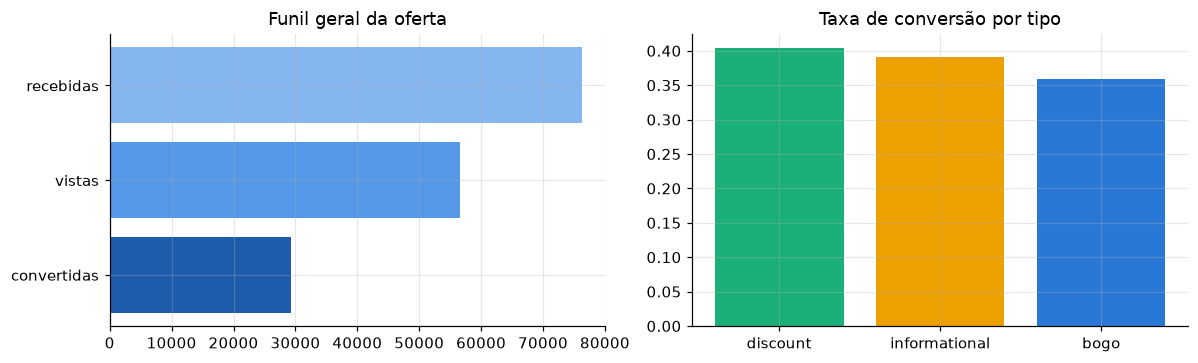

In [16]:
funil = [jornada.count(), jornada.agg(F.sum("visualizou")).first()[0], jornada.agg(F.sum("converteu")).first()[0]]

fig, eixos = plt.subplots(1, 2, figsize=(11, 3.4))
eixos[0].barh(["convertidas", "vistas", "recebidas"], funil[::-1], color=["#1c5cab", "#5598e7", "#86b6ef"])
eixos[0].set_title("Funil geral da oferta")
ordenado = resumo_tipo.sort_values("taxa_conversao", ascending=False)
eixos[1].bar(ordenado["tipo_oferta"], ordenado["taxa_conversao"], color=[COR_POR_TIPO[t] for t in ordenado["tipo_oferta"]])
eixos[1].set_title("Taxa de conversão por tipo")
fig.tight_layout()
plt.show()

Leitura do funil:

- As checagens de consistência zeram: nenhum evento atribuído fora da janela e nenhuma conversão sem visualização.
- Desconto converte mais que BOGO (40,4% contra 35,9%), apesar de o BOGO ser mais visto (82,8% contra 70,0%). Atenção não é o gargalo do BOGO, a mecânica persuade menos.
- Informacionais marcam 39,1%, mas sob régua mais branda (compra pós-visualização, sem gasto mínimo), então o número não é comparável diretamente. A decisão de enviá-las é econômica e fica para o notebook 2.
- A conversão acidental é relevante: 9.834 envios (16% de BOGO e desconto) tiveram desconto creditado sem visualização. Excluir esses casos do alvo evita que o modelo recomende ofertas a quem converteria sozinho.

## 6. Features comportamentais (sem vazamento)

Toda feature usa apenas eventos estritamente anteriores ao recebimento de cada envio. Isso vale inclusive para o desfecho de ofertas anteriores: uma oferta anterior só conta como vista ou convertida se o evento aconteceu antes do envio atual, pois janelas sobrepostas vazariam o futuro.

In [17]:
historico_compras = (
    envios.select("id_cliente", "id_envio", "dia_recebimento")
    .join(compras, "id_cliente")
    .filter(F.col("dia_compra") < F.col("dia_recebimento"))
    .groupBy("id_cliente", "id_envio")
    .agg(
        F.count("*").alias("num_transacoes_antes"),
        F.sum("valor_transacao").alias("gasto_total_antes"),
        F.avg("valor_transacao").alias("ticket_medio_antes"),
        F.max("dia_compra").alias("dia_ultima_compra"),
    )
)

anteriores = jornada.select(
    "id_cliente",
    F.col("dia_recebimento").alias("dia_recebimento_ant"),
    F.col("tipo_oferta").alias("tipo_ant"),
    F.col("dia_visualizacao").alias("dia_visualizacao_ant"),
    F.col("converteu").alias("converteu_ant"),
    F.col("dia_conversao").alias("dia_conversao_ant"),
)
historico_ofertas = (
    envios.select("id_cliente", "id_envio", "dia_recebimento", "tipo_oferta")
    .join(anteriores, "id_cliente")
    .filter(F.col("dia_recebimento_ant") < F.col("dia_recebimento"))
    .withColumn("vista_antes", F.when(F.col("dia_visualizacao_ant") < F.col("dia_recebimento"), 1).otherwise(0))
    .withColumn(
        "convertida_antes",
        F.when((F.col("converteu_ant") == 1) & (F.col("dia_conversao_ant") < F.col("dia_recebimento")), 1).otherwise(0),
    )
    .withColumn("mesmo_tipo", (F.col("tipo_ant") == F.col("tipo_oferta")).cast("int"))
    .groupBy("id_cliente", "id_envio")
    .agg(
        F.count("*").alias("ofertas_recebidas_antes"),
        F.sum("vista_antes").alias("ofertas_vistas_antes"),
        F.sum("convertida_antes").alias("ofertas_convertidas_antes"),
        F.sum("mesmo_tipo").alias("recebidas_mesmo_tipo_antes"),
        F.sum(F.col("mesmo_tipo") * F.col("convertida_antes")).alias("convertidas_mesmo_tipo_antes"),
    )
)

## 7. Dataset unificado

Jornada, histórico transacional, histórico de ofertas e atributos do cliente. Contagens ausentes viram zero. `ticket_medio_antes` e `recencia_ultima_compra` ficam nulos quando não há compra anterior, pois imputar zero criaria um falso sinal (a imputação é decisão do notebook 2). As colunas de desfecho (`visualizou`, `gasto_na_janela` etc.) ficam no dataset para a simulação de impacto, mas não são features.

In [18]:
taxa = lambda numerador, denominador: F.when(F.col(denominador) > 0, F.col(numerador) / F.col(denominador)).otherwise(F.lit(0.0))

dataset = (
    jornada.join(historico_compras, ["id_cliente", "id_envio"], "left")
    .join(historico_ofertas, ["id_cliente", "id_envio"], "left")
    .join(clientes, "id_cliente")
    .fillna({c: 0 for c in [
        "num_transacoes_antes", "gasto_total_antes", "ofertas_recebidas_antes", "ofertas_vistas_antes",
        "ofertas_convertidas_antes", "recebidas_mesmo_tipo_antes", "convertidas_mesmo_tipo_antes",
    ]})
    .withColumn("recencia_ultima_compra", F.col("dia_recebimento") - F.col("dia_ultima_compra"))
    .withColumn("taxa_visualizacao_previa", taxa("ofertas_vistas_antes", "ofertas_recebidas_antes"))
    .withColumn("taxa_conversao_previa", taxa("ofertas_convertidas_antes", "ofertas_recebidas_antes"))
    .withColumn("taxa_conversao_previa_mesmo_tipo", taxa("convertidas_mesmo_tipo_antes", "recebidas_mesmo_tipo_antes"))
    .drop("dia_ultima_compra", "dia_visualizacao", "dia_conclusao", "dia_compra_apos_ver", "dia_conversao", "informacional")
)

print("dataset final:", dataset.count(), "linhas x", len(dataset.columns), "colunas")
dataset.limit(3).toPandas()

dataset final: 76277 linhas x 37 colunas


,id_cliente,id_envio,id_oferta,dia_recebimento,tipo_oferta,valor_minimo,duracao_dias,valor_desconto,num_canais,canal_web,...,idade,genero,limite_cartao,cadastro_incompleto,tempo_cadastro_dias,ano_cadastro,recencia_ultima_compra,taxa_visualizacao_previa,taxa_conversao_previa,taxa_conversao_previa_mesmo_tipo
0,0020c2b971eb4e9188eac86d93036a77,1,fafdcd668e3743c1bb461111dcafc2a4,0.0,discount,10,10.0,2,4,1,...,59,F,90000.0,0,874,2016,NaN,0.000000,0.000000,0.0
1,0020c2b971eb4e9188eac86d93036a77,4,4d5c57ea9a6940dd891ad53e9dbe8da0,17.0,bogo,10,5.0,10,4,1,...,59,F,90000.0,0,874,2016,11.00,0.333333,0.333333,0.0
2,0056df74b63b4298809f0b375a304cf4,4,2298d6c36e964ae4a3e7e9706d1fb8c2,24.0,discount,7,7.0,3,4,1,...,54,M,91000.0,0,704,2016,0.75,0.666667,0.666667,0.0


In [19]:
caminho_dataset = PROCESSED / "dataset_ofertas.parquet"
dataset.toPandas().to_parquet(caminho_dataset, index=False)

conferencia = spark.read.parquet(str(caminho_dataset))
print(conferencia.count(), "linhas relidas")
conferencia.groupBy("tipo_oferta").agg(F.round(F.avg("converteu"), 4).alias("taxa_conversao")).show()

76277 linhas relidas


+-------------+--------------+
|  tipo_oferta|taxa_conversao|
+-------------+--------------+
|     discount|        0.4036|
|         bogo|        0.3587|
|informational|        0.3908|
+-------------+--------------+



O dataset é pequeno (76 mil linhas), então gravamos um único Parquet via pandas, formato portátil para o scikit-learn, o LightGBM e o Streamlit, e que dispensa os binários Hadoop (winutils) exigidos pela escrita nativa do Spark no Windows. Em Databricks ou Linux, `dataset.write.parquet(...)` é o equivalente direto.

### Snapshot por cliente

Para recomendar a próxima oferta, o notebook 2 precisa do retrato mais atual de cada cliente: comportamento consolidado até o fim do teste, com os mesmos nomes das features de treino. O histórico por tipo fica pivotado (`recebidas_bogo`, `convertidas_discount`, ...), pois na grade de escoragem as features de mesmo tipo dependem da oferta avaliada. Inclui os 17.000 clientes, mesmo os 6 sem envio.

In [20]:
fim_do_teste = eventos.agg(F.max("dia_evento")).first()[0]

comportamento_final = compras.groupBy("id_cliente").agg(
    F.count("*").alias("num_transacoes_antes"),
    F.sum("valor_transacao").alias("gasto_total_antes"),
    F.avg("valor_transacao").alias("ticket_medio_antes"),
    (F.lit(fim_do_teste) - F.max("dia_compra")).alias("recencia_ultima_compra"),
)
historico_final = jornada.groupBy("id_cliente").agg(
    F.count("*").alias("ofertas_recebidas_antes"),
    F.sum("visualizou").alias("ofertas_vistas_antes"),
    F.sum("converteu").alias("ofertas_convertidas_antes"),
)
por_tipo_final = (
    jornada.groupBy("id_cliente")
    .pivot("tipo_oferta", ["bogo", "discount", "informational"])
    .agg(F.count("*").alias("recebidas"), F.sum("converteu").alias("convertidas"))
    .withColumnsRenamed({f"{t}_{m}": f"{m}_{t}" for t in ["bogo", "discount", "informational"] for m in ["recebidas", "convertidas"]})
)

snapshot = (
    clientes.join(comportamento_final, "id_cliente", "left")
    .join(historico_final, "id_cliente", "left")
    .join(por_tipo_final, "id_cliente", "left")
    .fillna(0, subset=[c for c in ["num_transacoes_antes", "gasto_total_antes", "ofertas_recebidas_antes",
                                   "ofertas_vistas_antes", "ofertas_convertidas_antes"]
                       + [f"{m}_{t}" for t in ["bogo", "discount", "informational"] for m in ["recebidas", "convertidas"]]])
    .withColumn("taxa_visualizacao_previa", taxa("ofertas_vistas_antes", "ofertas_recebidas_antes"))
    .withColumn("taxa_conversao_previa", taxa("ofertas_convertidas_antes", "ofertas_recebidas_antes"))
)

snapshot.toPandas().to_parquet(PROCESSED / "clientes_snapshot.parquet", index=False)
print(snapshot.count(), "clientes gravados em clientes_snapshot.parquet")

17000 clientes gravados em clientes_snapshot.parquet


## 8. Premissas assumidas

1. `time_since_test_start` está em dias, mesma unidade de `duration`; a janela de validade é `dia_recebimento + duracao_dias`.
2. O grão é o evento de recebimento: o mesmo cliente pode receber a mesma oferta mais de uma vez, cada envio com jornada própria.
3. Atribuição de último toque: eventos de visualização e conclusão vão para o envio mais recente cuja janela os contém, cada evento conta no máximo uma vez, e por envio valem a primeira visualização e a primeira conclusão.
4. Conversão de BOGO e desconto exige visualização antes da conclusão, ambas na janela (empate no mesmo instante conta como visto antes).
5. Conclusão sem visualização prévia é conversão acidental e recebe `converteu = 0`.
6. Informacionais convertem com visualização seguida de transação até o fim da janela.
7. Idade 118 é placeholder de cadastro incompleto (coincide com gênero e limite nulos em 2.175 clientes); os clientes são mantidos com flag.
8. A referência de tempo de cadastro é a maior data de cadastro da base (26/07/2018); a ordenação relativa entre clientes está preservada.
9. Outliers de valor de transação são compras legítimas e foram mantidos; o `reward` do evento é redundante com o `valor_desconto` da oferta.
10. Features usam somente eventos estritamente anteriores ao recebimento, inclusive desfechos de ofertas anteriores.
11. Os 6 clientes sem oferta recebida não têm linha no dataset de treino, mas entram no snapshot de recomendação.
12. Empates de ordenação são resolvidos por `id_oferta` para garantir reprodutibilidade.

Saídas em `data/processed/`: `dataset_ofertas.parquet` (treino) e `clientes_snapshot.parquet` (escoragem das recomendações no notebook 2).